In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
import pickle

# define species and username so that the files can be found
species = "Panthera_tigris"

# For running it locally
if os.getcwd().startswith("/home/lakrids"):
    path_prefix = "/home/lakrids/GenomeDK"
else:
    path_prefix = "/faststorage/project/"

with open(f"{path_prefix}/megaFauna/sa_megafauna/data/{species}/ref/parameters_{species}.pkl", "rb") as f: 
    params = pickle.load(f)

generation = params.get("generation")
colour = params.get("colour")

In [ ]:
ne_df = pd.read_csv(f"{path_prefix}/megaFauna/sa_megafauna/results/{species}/GONE/chrA_India_NE_{recomb}_GONE2_Ne", sep="\t")

ne_df["time_years_ago"] = ne_df["Generation"] * generation
ne_df[:10]

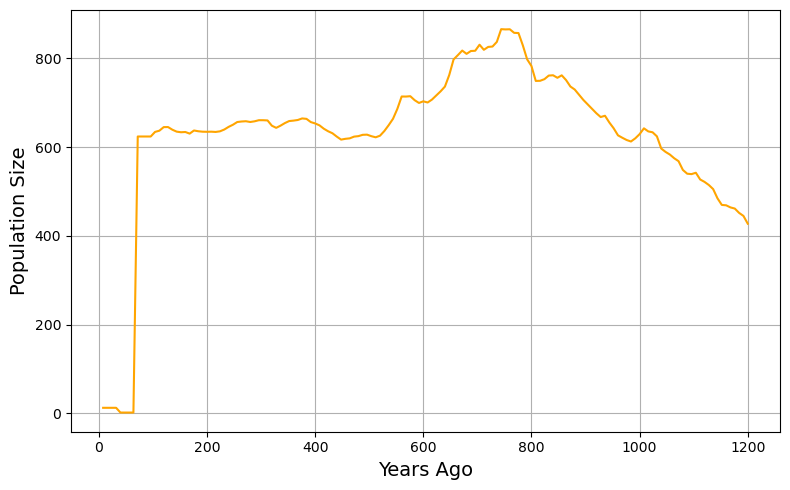

In [ ]:
# Plotting
plt.figure(figsize=(8, 5))
plt.plot(ne_df["time_years_ago"], ne_df["Ne_diploids"], linestyle='-', color=colour)
plt.gca()  # Optional: makes the most recent generation appear on the left
#plt.title(f"Past effective population sizes {species} (GONE2)")
plt.xlabel("Years Ago", fontsize=14)
plt.ylabel("Population Size", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.gca() # so it matches the paper figure
plt.show()

After filtering for missingness: 7673502 SNPs
Before filtering for missingness: 8405148 SNPs

# Human impact
*Antonia is intruding* *dangerous and omnious music starts to play

## Demography

In [2]:
# input human impact csv
human_impact_indiandemography = pd.read_csv(f'{path_prefix}/megaFauna/sa_megafauna/data/human_impact/India_demography_humanimpact_combined.csv')

human_impact_indiandemography

,Year,India - Population [inh],India - Urban Population [inh],India - Rural Population [km²],India - Population Density [inh/km²]
0,-10000,8.481063e+04,0.000000e+00,8.481063e+04,0.027138
1,-9000,1.671510e+05,2.400858e+02,1.669110e+05,0.053485
2,-8000,3.294336e+05,6.309050e+02,3.288027e+05,0.105413
3,-7000,6.492721e+05,1.657912e+03,6.476141e+05,0.207755
4,-6000,1.279633e+06,4.356714e+03,1.275277e+06,0.409459
...,...,...,...,...,...
121,2019,1.371661e+09,4.822851e+08,8.893760e+08,438.906371
122,2020,1.388008e+09,4.959762e+08,8.920315e+08,444.136967
123,2021,1.402057e+09,5.092039e+08,8.928535e+08,448.632627
124,2022,1.416107e+09,5.225961e+08,8.935111e+08,453.128288


In [3]:
# some data wrangling to get the years up to the same axis :)
reference_year = 2026
ne_df["Year"] = reference_year - ne_df["time_years_ago"]
ne_df

NameError: name 'ne_df' is not defined

In [ ]:
# Variables to compare
variables = [
    "India - Population [inh]",
    "India - Urban Population [inh]",
    "India - Rural Population [km²]",
    "India - Population Density [inh/km²]"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, col in enumerate(variables):
    ax = axes[i]
    
    # Plot India variable
    ax.plot(human_impact_indiandemography["Year"], human_impact_indiandemography[col], color="#7f64b9", linestyle="--", label=col)
    
    # Plot Ne_diploids on secondary axis
    ax2 = ax.twinx()
    ax2.plot(ne_df["Year"], ne_df["Ne_diploids"], color="#72ac5c", label="Ne_diploids")
    
    # Labels
    ax.set_title(f"{col} vs Ne_diploids")
    ax.set_xlabel("Year")
    ax.set_ylabel(col, color="#72ac5c")
    ax2.set_ylabel("Ne_diploids", color="#7f64b9")
    
    # Legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper left")

plt.tight_layout()
plt.xlim((1275, 2025))

# Generate ticks every 100 years
xticks = np.arange(1275, 2025+1, 100)
for ax in axes:
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", rotation=45)

plt.show()

## Landuse

In [ ]:
# input human impact csv - landuse
human_impact_indianlanduse = pd.read_csv(f'{path_prefix}/megaFauna/sa_megafauna/data/human_impact/landuse_humanimpact_combined.csv')
human_impact_indianlanduse

In [ ]:
# Variables to compare
variables = [
    "India - Urban Area [km²]",
    "India - Cropland [km²]",
    "India - Grazing Land [km²]",
    "India - Pasture [km²]",
    "India - Rangeland [km²]",
    "India - Converted Rangeland [km²]"
]

fig, axes = plt.subplots(3, 2, figsize=(21, 15), sharex=True)
axes = axes.flatten()

for i, col in enumerate(variables):
    ax = axes[i]
    
    # Plot India variable
    ax.plot(human_impact_indianlanduse["Year"], human_impact_indianlanduse[col], color="#7f64b9", linestyle="--", label=col)
    
    # Plot Ne_diploids on secondary axis
    ax2 = ax.twinx()
    ax2.plot(ne_df["Year"], ne_df["Ne_diploids"], color="#72ac5c", label="Ne_diploids")
    
    # Labels
    ax.set_title(f"{col} vs Ne_diploids")
    ax.set_xlabel("Year")
    ax.set_ylabel(col, color="#7f64b9")
    ax2.set_ylabel("Ne_diploids", color="#72ac5c")
    
    # Legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper left")

plt.tight_layout()
plt.xlim((1275, 2025))

# Generate ticks every 100 years
xticks = np.arange(1275, 2025+1, 100)
for ax in axes:
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", rotation=45)

plt.show()

## For the report

In [ ]:
# input human impact csv
human_impact_indiandemography = pd.read_csv(f'{path_prefix}/megaFauna/sa_megafauna/data/human_impact/India_demography_humanimpact_combined.csv')
human_impact_indiandemography

# input human impact csv - landuse
human_impact_indianlanduse = pd.read_csv(f'{path_prefix}/megaFauna/sa_megafauna/data/human_impact/landuse_humanimpact_combined.csv')
human_impact_indianlanduse

merged_impact = pd.merge(
    human_impact_indiandemography,
    human_impact_indianlanduse,
    on="Year",
    how="inner"   # keeps only years present in both
)
merged_impact

# choose human vars you want to plot
human_vars = [
    "India - Population [inh]",
    "India - Urban Area [km²]",
    "India - Grazing Land [km²]"
]

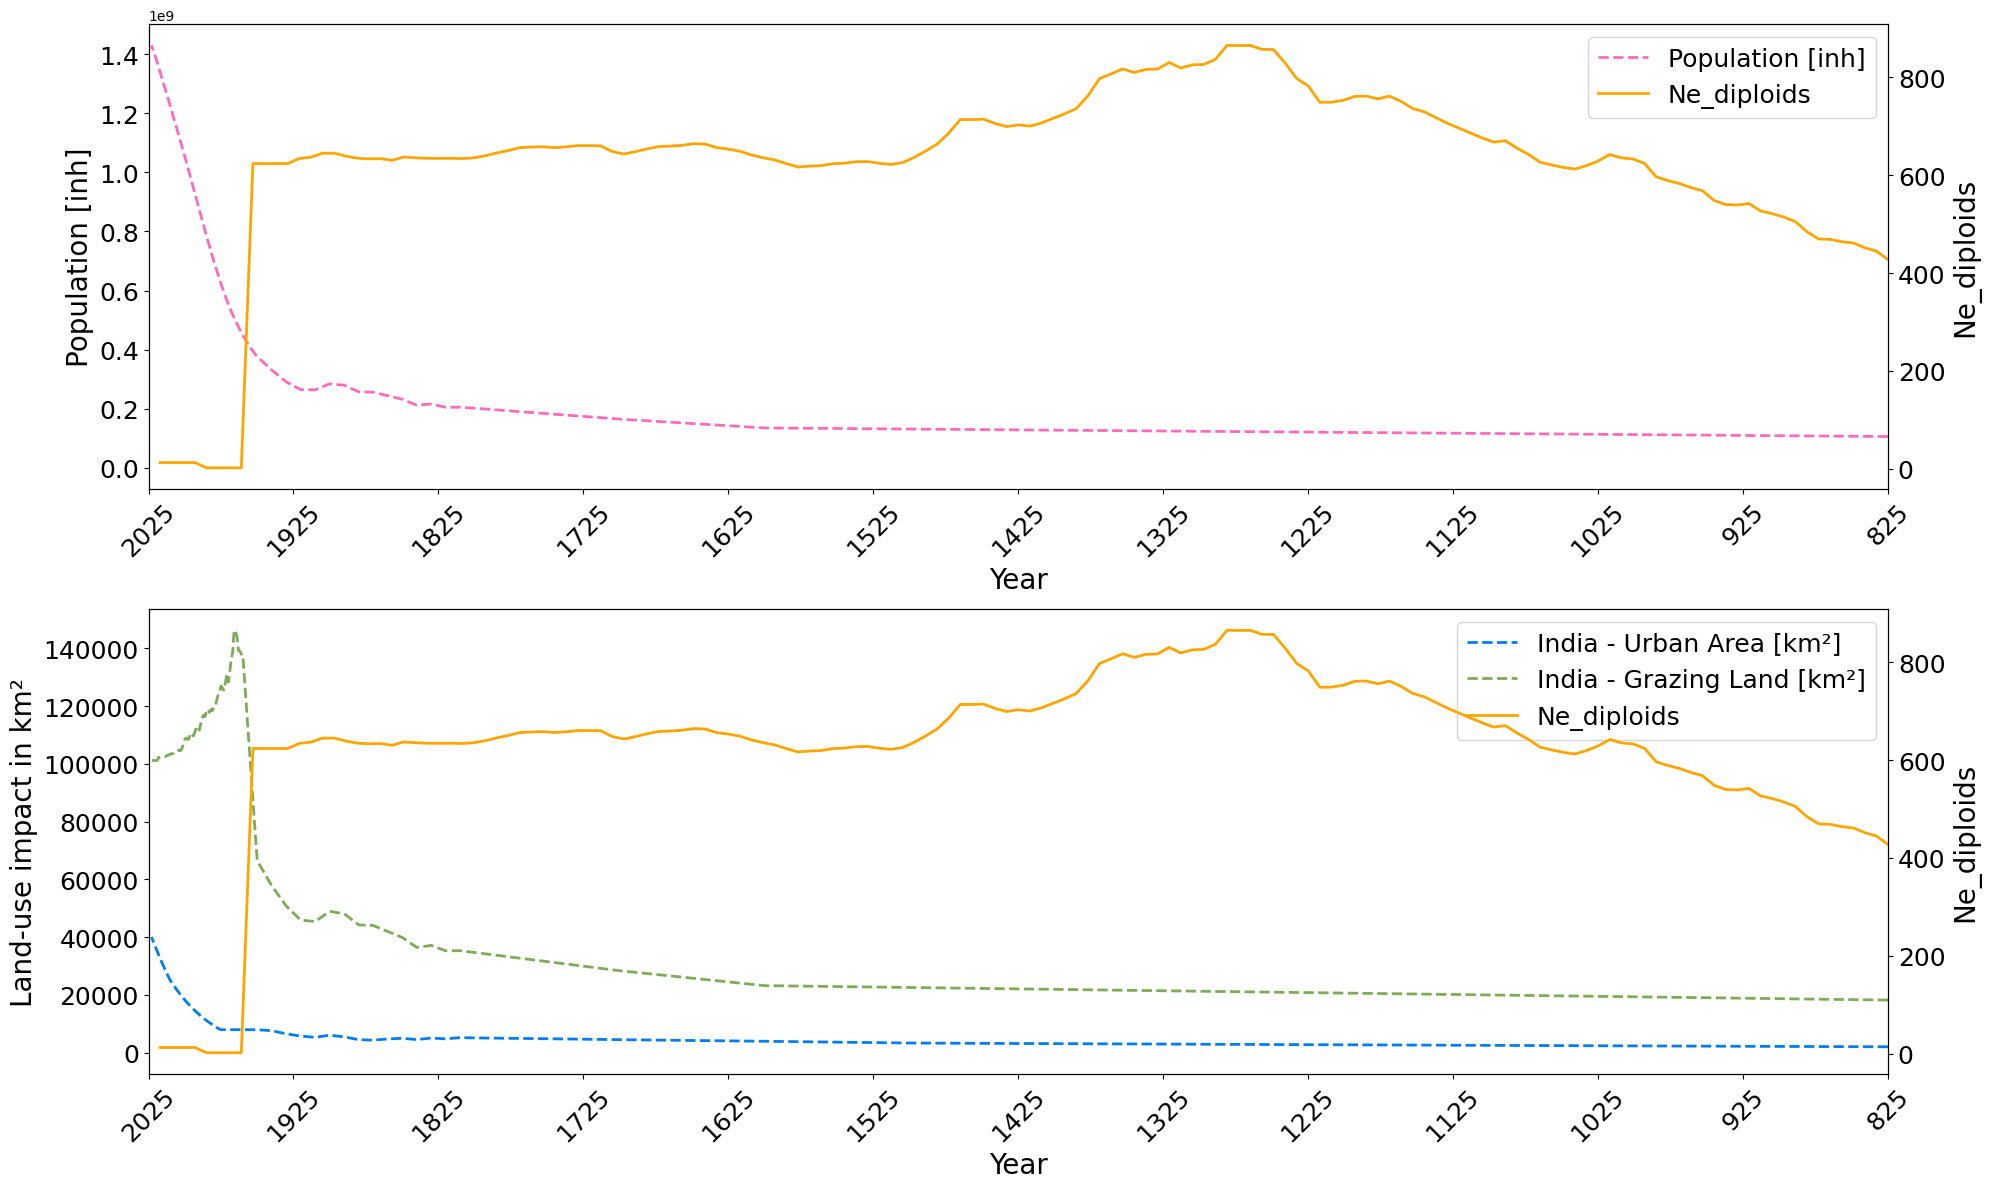

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12), sharey=False)

# --- Left plot: Population vs Ne_diploids ---
ax1.plot(
    merged_impact["Year"],
    merged_impact["India - Population [inh]"],
    linestyle="--",
    color="#ff6bbc",
    linewidth=2,
    label="Population [inh]"
)

ax1.set_xlabel("Year", fontsize = 20)
ax1.set_ylabel("Population [inh]", fontsize = 20)

# Secondary axis for Ne_diploids
ax1b = ax1.twinx()
ax1b.plot(
    ne_df["Year"],
    ne_df["Ne_diploids"],
    linewidth=2,
    color=colour,
    label="Ne_diploids"
)
ax1b.set_ylabel("Ne_diploids", fontsize = 20)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize = 18)

# --- Right plot: Urban Area & Grazing Land vs Ne_diploids ---
colors = ["#017df0", "#7eab57"]  # orange, green
for col, color in zip(["India - Urban Area [km²]", "India - Grazing Land [km²]"], colors):
    ax2.plot(
        merged_impact["Year"],
        merged_impact[col],
        linestyle="--",
        color=color,
        linewidth=2,
        label=col
    )

ax2.set_xlabel("Year", fontsize = 20)
ax2.set_ylabel("Land-use impact in km²", fontsize = 20)

# Secondary axis for Ne_diploids
ax2b = ax2.twinx()
ax2b.plot(
    ne_df["Year"],
    ne_df["Ne_diploids"],
    linewidth=2,
    color=colour,
    label="Ne_diploids"
)
ax2b.set_ylabel("Ne_diploids", fontsize = 20)

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize = 18)

# Formatting
for ax in [ax1, ax2]:
    ax1.set_xlim(2025, 825) # recent years on the left, older on the right
    ax2.set_xlim(2025, 825)
    xticks = np.arange(825, 2025 + 1, 100)
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", rotation=45, labelsize = 18)
    ax.tick_params(axis="y", labelsize=18)

# Apply to the twin y-axes as well
ax1b.tick_params(axis="y", labelsize=18)
ax2b.tick_params(axis="y", labelsize=18)

plt.tight_layout()

plt.tight_layout()

#plt.savefig("/faststorage/project/megaFauna/people/amlg/plots/human_impact/human_impact_vs_ne_pantheratigris_biglabels.png", dpi=600)

plt.show()

## Compute Spearman's Rank Correlations
To have something concrete to mention in our report - for more details aka the how and why look in @antonias GONE2.ipynb script.

In [9]:
# idea: interpolate the human impact variables (they are smooth and slow changing, so it should work). You still need to be careful though.
# Step 1: Create a full year range covering Ne_diploids years 
full_years = pd.DataFrame({"Year": ne_df["Year"]})
full_years

# Step 1: Create a full year range covering Ne_diploids years
full_years = pd.DataFrame({"Year": ne_df["Year"]})

# Step 2: Reindex human impact data to this full range
impact_full = (
    merged_impact.set_index("Year")
    .reindex(full_years["Year"])  # this adds missing years as NaN
    .interpolate(method="index", limit_direction="both")  # interpolate + extrapolate
    .reset_index()
)

In [10]:
impact_full

,Year,India - Population [inh],India - Urban Population [inh],India - Rural Population [km²],India - Population Density [inh/km²],India - Urban Area [km²],India - Cropland [km²],India - Grazing Land [km²],India - Pasture [km²],India - Rangeland [km²],India - Converted Rangeland [km²]
0,2017,1.338968e+09,4.554643e+08,8.835037e+08,428.445179,32651.749513,1.688782e+06,102259.329806,61006.485179,32997.973442,8254.871185
1,2009,1.207629e+09,3.592191e+08,8.484098e+08,386.419065,24273.549450,1.691550e+06,103441.593036,62726.331106,32254.492619,8460.769312
2,2001,1.071064e+09,2.959600e+08,7.751039e+08,342.720795,18871.973855,1.692797e+06,106623.145932,65662.184564,32220.707425,8740.253943
3,1993,9.281518e+08,2.400036e+08,6.881482e+08,296.991526,14582.096802,1.696724e+06,110960.642928,65800.192977,35735.113792,9425.336159
4,1985,7.844464e+08,1.886315e+08,5.958149e+08,251.008433,11130.702812,1.687296e+06,118504.692721,70136.087067,38249.842689,10118.762964
...,...,...,...,...,...,...,...,...,...,...,...
145,857,3.951388e+08,6.837228e+07,3.267665e+08,126.437157,7972.268299,1.526717e+06,87518.678192,51209.803148,28662.321244,7646.553799
146,849,3.951388e+08,6.837228e+07,3.267665e+08,126.437157,7972.268299,1.526717e+06,87518.678192,51209.803148,28662.321244,7646.553799
147,841,3.951388e+08,6.837228e+07,3.267665e+08,126.437157,7972.268299,1.526717e+06,87518.678192,51209.803148,28662.321244,7646.553799
148,833,3.951388e+08,6.837228e+07,3.267665e+08,126.437157,7972.268299,1.526717e+06,87518.678192,51209.803148,28662.321244,7646.553799


In [11]:
# Step 3: Merge with Ne_diploids
aligned = ne_df[["Year", "Ne_diploids"]].merge(
    impact_full[["Year"] + human_vars],
    on="Year",
    how="left"
)

In [12]:
aligned

,Year,Ne_diploids,India - Population [inh],India - Urban Area [km²],India - Grazing Land [km²]
0,2017,12.63250,1.338968e+09,32651.749513,102259.329806
1,2009,12.63250,1.207629e+09,24273.549450,103441.593036
2,2001,12.63250,1.071064e+09,18871.973855,106623.145932
3,1993,12.63250,9.281518e+08,14582.096802,110960.642928
4,1985,1.94276,7.844464e+08,11130.702812,118504.692721
...,...,...,...,...,...
145,857,463.97900,3.951388e+08,7972.268299,87518.678192
146,849,461.39400,3.951388e+08,7972.268299,87518.678192
147,841,451.62500,3.951388e+08,7972.268299,87518.678192
148,833,444.81900,3.951388e+08,7972.268299,87518.678192


In [14]:
"""
Use scipy.stats.spearmanr to calculate the correlation between each variable in human_vars and Ne_diploids:
"""
# Step 4: Drop any remaining NaNs
aligned = aligned.dropna()

# Step 5: Compute Spearman correlations
correlations = {}

for var in human_vars:
    rho, pval = spearmanr(aligned[var], aligned["Ne_diploids"])
    correlations[var] = (rho, pval)
correlations

{'India - Population [inh]': (-0.3887229687113738, 8.843537835679104e-07),
 'India - Urban Area [km²]': (-0.2888757374604303, 0.00033690043706104594),
 'India - Grazing Land [km²]': (-0.38930740467260116, 8.487962694518176e-07)}